# Phase 3B: MST Feature Exploration

This notebook inspects the objective DIFF-MST-derived stimulus features that will later support a feature-based Bayesian mixed-effects model. It does not fit a statistical model. The aim is to validate coverage, understand variation, inspect Bark Spectrum representation, assess multicollinearity risk, and recommend a defensible feature representation for the dissertation.

## 1. Imports and Project-Relative Paths

All file paths are resolved from the repository root so the notebook can execute from different Jupyter launch directories.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.plotting import scatter_matrix

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "stimulus_selection.yaml").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "outputs" / "statistical_baseline" / "mst_feature_exploration"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Repository root: {REPO_ROOT}")
print(f"Output directory: {OUTPUT_DIR.relative_to(REPO_ROOT)}")

Python: 3.10.14
Repository root: C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1. Master Program\3. MSc Project\intent2control-dissertation
Output directory: outputs\statistical_baseline\mst_feature_exploration


## 2. Load Available Feature Sources

The notebook automatically loads the repository feature tables when present. The authoritative source for the twelve active final-study stimuli is `outputs/stimulus_selection/09_current_frontend_integration/tables/current_frontend_stimuli.csv`, derived from `study-interface/frontend/config/stimuli.json`. The authoritative source for raw objective feature values is `raw_diffmst_features.csv`; Stage 4 v2 processed tables are used to understand corrected acoustic candidate-pool scaling, PCA, and selection diagnostics.

In [2]:
SOURCE_PATHS = {
    "raw_diffmst_features": REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "raw_diffmst_features.csv",
    "feature_schema": REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "feature_schema.json",
    "processed_features": REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "processed_features_v2.csv",
    "bark_pca_scores": REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "bark_pca_scores_v2.csv",
    "bark_pca_explained_variance": REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "bark_pca_explained_variance_v2.csv",
    "bark_pca_loadings": REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "bark_pca_loadings_v2.csv",
    "final_mix_selection_summary": REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "acoustic_candidate_pool_summary.csv",
    "final_selected_mixes": REPO_ROOT / "outputs" / "stimulus_selection" / "09_current_frontend_integration" / "tables" / "current_frontend_stimuli.csv",
}

loaded = {}
file_rows = []
descriptions = {
    "raw_diffmst_features": "Raw extracted DIFF-MST features for retained mixes; authoritative raw scalar and Bark-band values.",
    "feature_schema": "Definitions and extraction parameters for raw DIFF-MST feature columns.",
    "processed_features": "Stage 4 within-song robust-scaled scalars, Bark PCA scores, and selection diagnostics.",
    "bark_pca_scores": "Bark-only PCA score table produced during Stage 4 mix selection.",
    "bark_pca_explained_variance": "Explained variance and retained-component flags for within-song Bark PCA.",
    "bark_pca_loadings": "PCA loadings for Bark components, useful for interpretation but not participant modelling directly.",
    "final_mix_selection_summary": "Corrected acoustic candidate-pool summary per song; legacy representative/contrast summaries are archived.",
    "final_selected_mixes": "Current active frontend-derived 12-stimulus inclusion list; perceptual approval pending.",
}

for name, path in SOURCE_PATHS.items():
    if not path.exists():
        file_rows.append({"name": name, "filename": str(path.relative_to(REPO_ROOT)), "loaded": False, "dimensions": None, "variables": None, "description": descriptions[name]})
        continue
    if path.suffix == ".json":
        obj = json.loads(path.read_text(encoding="utf-8"))
        loaded[name] = obj
        variables = [c.get("name") for c in obj.get("columns", [])][:20]
        dimensions = f"{len(obj.get('columns', []))} schema columns"
    else:
        df = pd.read_csv(path)
        loaded[name] = df
        variables = df.columns.tolist()
        dimensions = f"{df.shape[0]} rows x {df.shape[1]} columns"
    file_rows.append({"name": name, "filename": str(path.relative_to(REPO_ROOT)), "loaded": True, "dimensions": dimensions, "variables": variables, "description": descriptions[name]})

loaded_files_df = pd.DataFrame(file_rows)
display(loaded_files_df[["name", "filename", "loaded", "dimensions", "description"]])

required = ["raw_diffmst_features", "feature_schema", "processed_features", "bark_pca_scores", "bark_pca_explained_variance", "final_selected_mixes"]
missing_required = [name for name in required if name not in loaded]
if missing_required:
    raise FileNotFoundError(f"Missing required feature sources: {missing_required}")

,name,filename,loaded,dimensions,description
0,raw_diffmst_features,outputs\stimulus_selection\03_feature_extracti...,True,92 rows x 83 columns,Raw extracted DIFF-MST features for retained m...
1,feature_schema,outputs\stimulus_selection\03_feature_extracti...,True,81 schema columns,Definitions and extraction parameters for raw ...
2,processed_features,outputs\stimulus_selection\04_mix_selection_v2...,True,92 rows x 113 columns,"Stage 4 within-song robust-scaled scalars, Bar..."
3,bark_pca_scores,outputs\stimulus_selection\04_mix_selection_v2...,True,92 rows x 14 columns,Bark-only PCA score table produced during Stag...
4,bark_pca_explained_variance,outputs\stimulus_selection\04_mix_selection_v2...,True,88 rows x 6 columns,Explained variance and retained-component flag...
5,bark_pca_loadings,outputs\stimulus_selection\04_mix_selection_v2...,True,4224 rows x 6 columns,"PCA loadings for Bark components, useful for i..."
6,final_mix_selection_summary,outputs\stimulus_selection\04_mix_selection_v2...,True,4 rows x 13 columns,Corrected acoustic candidate-pool summary per ...
7,final_selected_mixes,outputs\stimulus_selection\09_current_frontend...,True,12 rows x 15 columns,Current active frontend-derived 12-stimulus in...


## 3. Verify Coverage for the Twelve Final Stimuli

The final-stimulus table is joined to raw and processed feature rows by internal `mix_id`. Neutral `song_id`, `mix_id`, and `stimulus_id` values are assigned for modelling compatibility, but these neutral mix IDs are not interpreted as perceptual categories across songs.

In [3]:
raw = loaded["raw_diffmst_features"].copy()
processed = loaded["processed_features"].copy()
final_selected = loaded["final_selected_mixes"].copy()
pca_scores = loaded["bark_pca_scores"].copy()
pca_variance = loaded["bark_pca_explained_variance"].copy()
schema = loaded["feature_schema"]

source_song_to_neutral = {
    "Lead Me": "Song_1",
    "Red To Blue": "Song_2",
    "In The Meantime": "Song_3",
    "Pouring Room": "Song_4",
}
slot_to_mix = {"mix_01": "Mix_1", "mix_02": "Mix_2", "mix_03": "Mix_3"}
scalar_raw_cols = ["rms_mean", "crest_factor_mean", "stereo_width", "stereo_imbalance"]
scalar_display = {"rms_mean": "RMS", "crest_factor_mean": "CF", "stereo_width": "SW", "stereo_imbalance": "SI"}
bark_cols = [c for c in raw.columns if c.startswith("bark_mid_") or c.startswith("bark_side_")]
bark_pc_cols = [c for c in processed.columns if c.startswith("bark_pc_")]

selected = (
    final_selected
    .assign(
        neutral_song_id=lambda d: d["song"].map(source_song_to_neutral),
        neutral_mix_id=lambda d: d["slot"].map(slot_to_mix),
    )
    .rename(columns={"internal_mix_id": "source_mix_id", "source_mix": "original_mix_name"})
)
selected["stimulus_id"] = selected["neutral_song_id"] + "_" + selected["neutral_mix_id"]

raw_subset = raw[["mix_id", *scalar_raw_cols, *bark_cols]].rename(columns={"mix_id": "source_mix_id"})
processed_subset_cols = ["mix_id", "distance_from_medoid", "nearest_neighbour_distance", "acoustic_outlier_score", "stereo_imbalance_qc_flag", "candidate_pool_selected", *[f"scaled_{c}" for c in scalar_raw_cols if f"scaled_{c}" in processed.columns], *bark_pc_cols]
processed_subset = processed[processed_subset_cols].rename(columns={"mix_id": "source_mix_id"})

stimulus_features = selected.merge(raw_subset, on="source_mix_id", how="left", validate="one_to_one")
stimulus_features = stimulus_features.merge(processed_subset, on="source_mix_id", how="left", validate="one_to_one")
stimulus_features = stimulus_features.rename(columns={**scalar_display, "neutral_song_id": "song_id", "neutral_mix_id": "mix_id"})
stimulus_features["BS_representation"] = "48 raw Bark mid/side bands; within-song Bark PCA scores available"

coverage_columns = ["stimulus_id", "song_id", "mix_id", "RMS", "CF", "SW", "SI", "BS_representation"]
coverage_table = stimulus_features[coverage_columns].copy()
coverage_table["missing_scalar_feature"] = coverage_table[["RMS", "CF", "SW", "SI"]].isna().any(axis=1)
coverage_table["missing_bark_bands"] = stimulus_features[bark_cols].isna().any(axis=1)
display(coverage_table)

coverage_checks = pd.DataFrame(
    [
        {"check": "twelve_final_stimuli", "passed": len(stimulus_features) == 12, "observed": len(stimulus_features), "expected": 12},
        {"check": "unique_stimulus_ids", "passed": stimulus_features["stimulus_id"].is_unique, "observed": stimulus_features["stimulus_id"].nunique(), "expected": 12},
        {"check": "raw_feature_match_for_every_stimulus", "passed": not coverage_table["missing_scalar_feature"].any(), "observed": int(coverage_table["missing_scalar_feature"].sum()), "expected": 0},
        {"check": "bark_band_match_for_every_stimulus", "passed": not coverage_table["missing_bark_bands"].any(), "observed": int(coverage_table["missing_bark_bands"].sum()), "expected": 0},
    ]
)
display(coverage_checks)
assert coverage_checks["passed"].all()

,stimulus_id,song_id,mix_id,RMS,CF,SW,SI,BS_representation,missing_scalar_feature,missing_bark_bands
0,Song_1_Mix_1,Song_1,Mix_1,0.059133,16.919521,0.017093,-0.012909,48 raw Bark mid/side bands; within-song Bark P...,False,False
1,Song_1_Mix_2,Song_1,Mix_2,0.058888,15.674652,0.149042,0.109931,48 raw Bark mid/side bands; within-song Bark P...,False,False
2,Song_1_Mix_3,Song_1,Mix_3,0.073005,20.146322,0.039276,-0.001436,48 raw Bark mid/side bands; within-song Bark P...,False,False
3,Song_2_Mix_1,Song_2,Mix_1,0.052424,16.348396,0.099568,0.006442,48 raw Bark mid/side bands; within-song Bark P...,False,False
4,Song_2_Mix_2,Song_2,Mix_2,0.050914,14.437307,0.111658,-0.033620,48 raw Bark mid/side bands; within-song Bark P...,False,False
5,Song_2_Mix_3,Song_2,Mix_3,0.043741,15.980901,0.022538,-0.009704,48 raw Bark mid/side bands; within-song Bark P...,False,False
6,Song_3_Mix_1,Song_3,Mix_1,0.053939,22.597927,0.157731,0.017041,48 raw Bark mid/side bands; within-song Bark P...,False,False
7,Song_3_Mix_2,Song_3,Mix_2,0.056002,14.114304,0.212649,-0.038596,48 raw Bark mid/side bands; within-song Bark P...,False,False
8,Song_3_Mix_3,Song_3,Mix_3,0.055812,16.636909,0.050501,-0.012766,48 raw Bark mid/side bands; within-song Bark P...,False,False
9,Song_4_Mix_1,Song_4,Mix_1,0.060191,16.515205,0.147395,-0.063830,48 raw Bark mid/side bands; within-song Bark P...,False,False


,check,passed,observed,expected
0,twelve_final_stimuli,True,12,12
1,unique_stimulus_ids,True,12,12
2,raw_feature_match_for_every_stimulus,True,0,0
3,bark_band_match_for_every_stimulus,True,0,0


## 4. Scalar Feature Distributions

The four scalar descriptors available for all twelve selected stimuli are RMS, crest factor (CF), stereo width (SW), and stereo imbalance (SI). They are descriptors, not quality scores.

,feature,count,mean,std,min,<lambda>,median,<lambda>,max,coefficient_of_variation,near_constant
0,RMS,12.0,0.057004,0.007013,0.043741,0.053560,0.057384,0.059397,0.073005,0.123032,False
1,CF,12.0,17.512661,2.696206,14.114304,15.904339,16.576057,19.990781,22.597927,0.153958,False
2,SW,12.0,0.114367,0.069666,0.017093,0.047695,0.129526,0.151214,0.217380,0.609139,False
3,SI,12.0,-0.009301,0.043986,-0.063830,-0.034864,-0.012837,0.000534,0.109931,4.729160,False


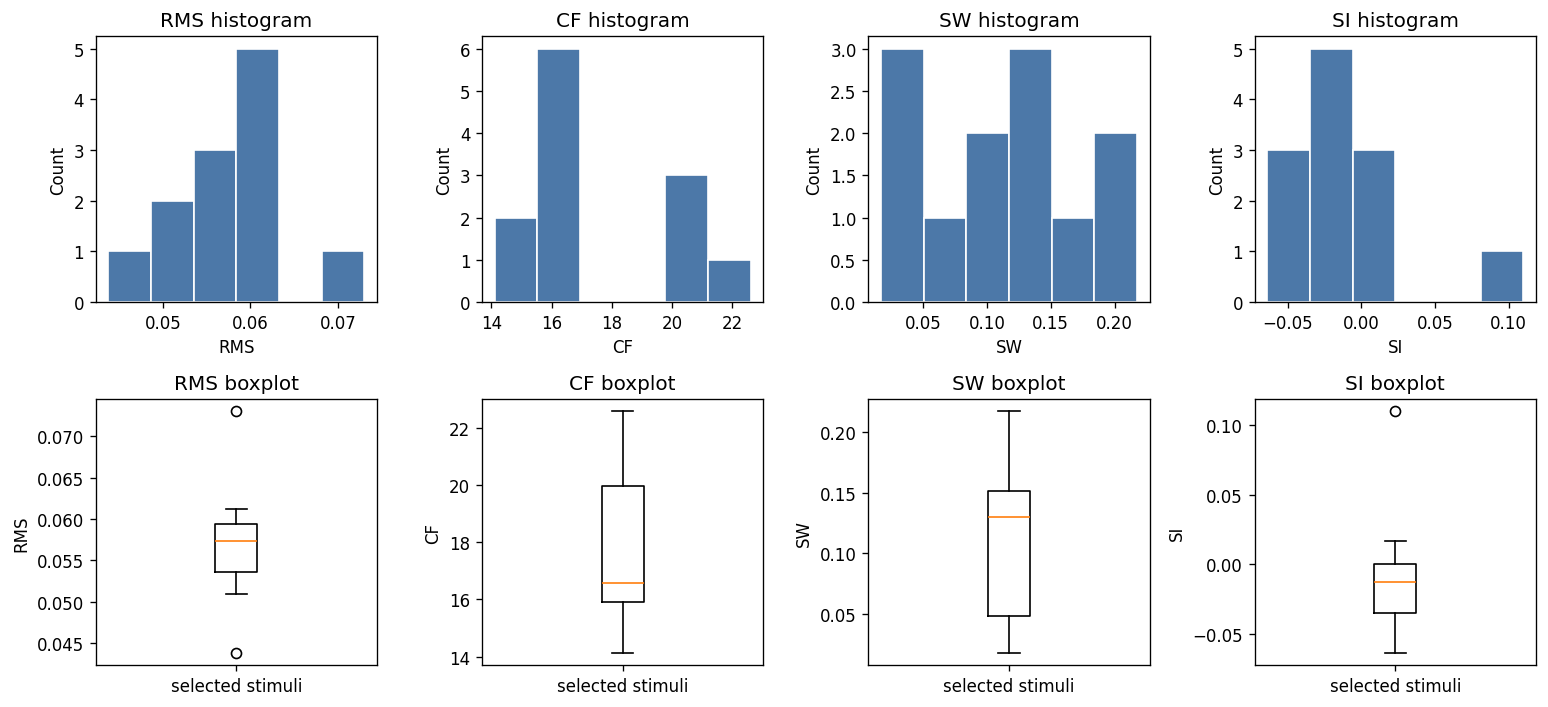

In [4]:
scalar_cols = ["RMS", "CF", "SW", "SI"]
scalar_df = stimulus_features[["stimulus_id", "song_id", "mix_id", *scalar_cols]].copy()
feature_summary = (
    scalar_df[scalar_cols]
    .agg(["count", "mean", "std", "min", lambda s: s.quantile(0.25), "median", lambda s: s.quantile(0.75), "max"])
    .rename(index={"<lambda_0>": "q25", "<lambda_1>": "q75"})
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)
feature_summary["coefficient_of_variation"] = feature_summary["std"] / feature_summary["mean"].abs()
feature_summary["near_constant"] = feature_summary["std"].fillna(0).lt(1e-8)
display(feature_summary.round(6))

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for idx, feature in enumerate(scalar_cols):
    axes[0, idx].hist(scalar_df[feature], bins=6, color="#4C78A8", edgecolor="white")
    axes[0, idx].set_title(f"{feature} histogram")
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel("Count")
    axes[1, idx].boxplot(scalar_df[feature], vert=True)
    axes[1, idx].set_title(f"{feature} boxplot")
    axes[1, idx].set_ylabel(feature)
    axes[1, idx].set_xticks([1])
    axes[1, idx].set_xticklabels(["selected stimuli"])
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scalar_feature_distributions.png")
plt.show()

## 5. Inspect Bark Spectrum Representation

The feature schema states that `compute_barkspectrum(..., mode='mid-side')` returns a `(batch, 24, 2)` tensor. The raw table stores this as 48 columns: `bark_mid_01` to `bark_mid_24` and `bark_side_01` to `bark_side_24`. There is no authoritative one-column BS scalar in the repository.

In [5]:
schema_notes = schema.get("notes", [])
schema_params = schema.get("extraction_parameters", {})
bark_mid_cols = [c for c in bark_cols if c.startswith("bark_mid_")]
bark_side_cols = [c for c in bark_cols if c.startswith("bark_side_")]

bark_representation = pd.DataFrame(
    [
        {"item": "raw_BS_columns", "value": len(bark_cols)},
        {"item": "mid_columns", "value": len(bark_mid_cols)},
        {"item": "side_columns", "value": len(bark_side_cols)},
        {"item": "schema_mapping", "value": schema_params.get("bark_tensor_mapping")},
        {"item": "units", "value": "natural log magnitude"},
        {"item": "scalar_BS_found", "value": False},
    ]
)
display(bark_representation)
print("Schema notes:")
for note in schema_notes:
    print(f"- {note}")

pca_retained_summary = (
    pca_variance
    .groupby(["artist", "song"], as_index=False)
    .agg(
        retained_components=("retained", "sum"),
        retained_cumulative_variance=("cumulative_explained_variance", lambda s: s[pca_variance.loc[s.index, "retained"]].max()),
        total_components=("component", "count"),
    )
)
display(pca_retained_summary.round(4))

,item,value
0,raw_BS_columns,48
1,mid_columns,24
2,side_columns,24
3,schema_mapping,"compute_barkspectrum(..., mode='mid-side') ret..."
4,units,natural log magnitude
5,scalar_BS_found,False


Schema notes:
- Features are descriptors, not quality scores.
- Stereo imbalance is signed.
- Bark values are log spectral-band values.
- Raw feature values must not be compared across different songs for final selection without within-song preprocessing.


,artist,song,retained_components,retained_cumulative_variance,total_components
0,Broken Crank,Red To Blue,5,0.9626,9
1,Fredy V,In The Meantime,8,0.9559,35
2,The DoneFors,Lead Me,9,0.9504,36
3,The DoneFors,Pouring Room,5,0.9705,8


The existing Bark PCA was fitted within each song after robust scaling. That is appropriate for Stage 4 mix selection, because final mix selection compared alternatives within the same song. It does not create a single global Bark coordinate system across all four songs.

## 6. Correlation Analysis and Multicollinearity

Correlations are calculated across the twelve final stimuli. With only twelve stimuli, these values should be treated as diagnostic rather than stable population estimates.

,RMS,CF,SW,SI
RMS,1.000,0.402,0.043,0.019
CF,0.402,1.000,0.143,-0.008
SW,0.043,0.143,1.000,-0.115
SI,0.019,-0.008,-0.115,1.000


,RMS,CF,SW,SI
RMS,1.000,0.399,0.049,-0.189
CF,0.399,1.000,0.056,0.098
SW,0.049,0.056,1.000,-0.238
SI,-0.189,0.098,-0.238,1.000


,method,feature_a,feature_b,r,abs_r,above_0_70,above_0_90
0,pearson,RMS,CF,0.402,0.402,False,False
1,pearson,CF,SW,0.143,0.143,False,False
2,pearson,SW,SI,-0.115,0.115,False,False
3,pearson,RMS,SW,0.043,0.043,False,False
4,pearson,RMS,SI,0.019,0.019,False,False
5,pearson,CF,SI,-0.008,0.008,False,False
6,spearman,RMS,CF,0.399,0.399,False,False
7,spearman,SW,SI,-0.238,0.238,False,False
8,spearman,RMS,SI,-0.189,0.189,False,False
9,spearman,CF,SI,0.098,0.098,False,False


C:\Users\oscar\AppData\Local\Temp\ipykernel_33184\4240960376.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


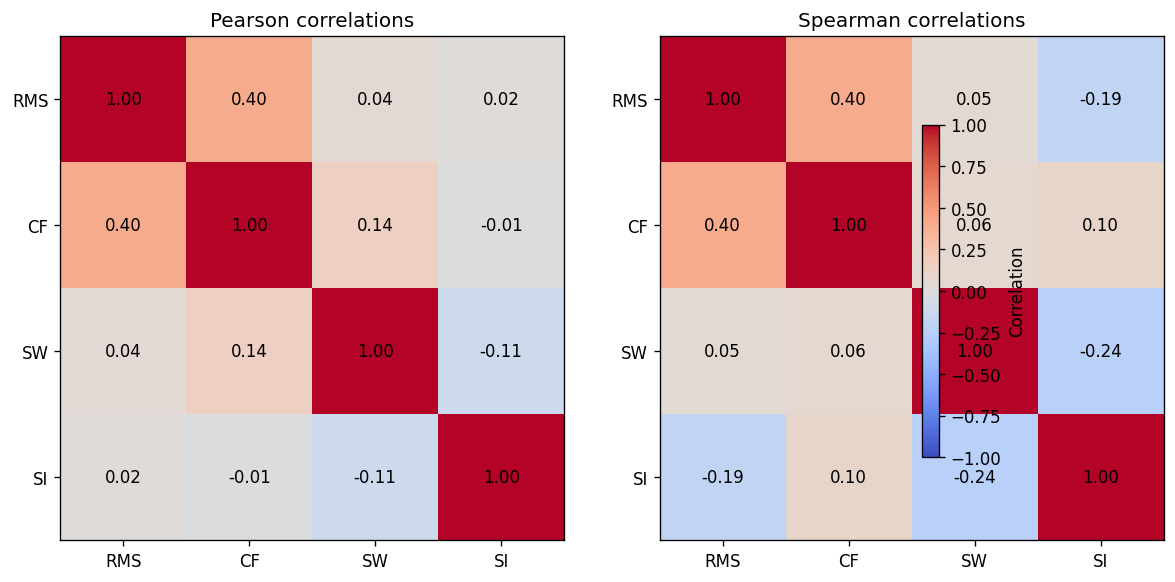

In [6]:
pearson_corr = scalar_df[scalar_cols].corr(method="pearson")
spearman_corr = scalar_df[scalar_cols].corr(method="spearman")
display(pearson_corr.round(3))
display(spearman_corr.round(3))

def high_corr_pairs(corr: pd.DataFrame, method: str) -> pd.DataFrame:
    rows = []
    for i, a in enumerate(corr.columns):
        for b in corr.columns[i + 1:]:
            r = corr.loc[a, b]
            rows.append({"method": method, "feature_a": a, "feature_b": b, "r": r, "abs_r": abs(r), "above_0_70": abs(r) > 0.70, "above_0_90": abs(r) > 0.90})
    return pd.DataFrame(rows).sort_values("abs_r", ascending=False)

correlation_flags = pd.concat([high_corr_pairs(pearson_corr, "pearson"), high_corr_pairs(spearman_corr, "spearman")], ignore_index=True)
display(correlation_flags.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, corr, title in [(axes[0], pearson_corr, "Pearson correlations"), (axes[1], spearman_corr, "Spearman correlations")]:
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(scalar_cols)))
    ax.set_xticklabels(scalar_cols)
    ax.set_yticks(range(len(scalar_cols)))
    ax.set_yticklabels(scalar_cols)
    ax.set_title(title)
    for i in range(len(scalar_cols)):
        for j in range(len(scalar_cols)):
            value = corr.iloc[i, j]
            weight = "bold" if i != j and abs(value) > 0.70 else "normal"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontweight=weight)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Correlation")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scalar_feature_correlations.png")
plt.show()

## 7. Pairwise Relationships

The scatterplot matrix labels each selected stimulus and colours points by song. This is a compact check for separation, clustering, and possible outlying combinations.

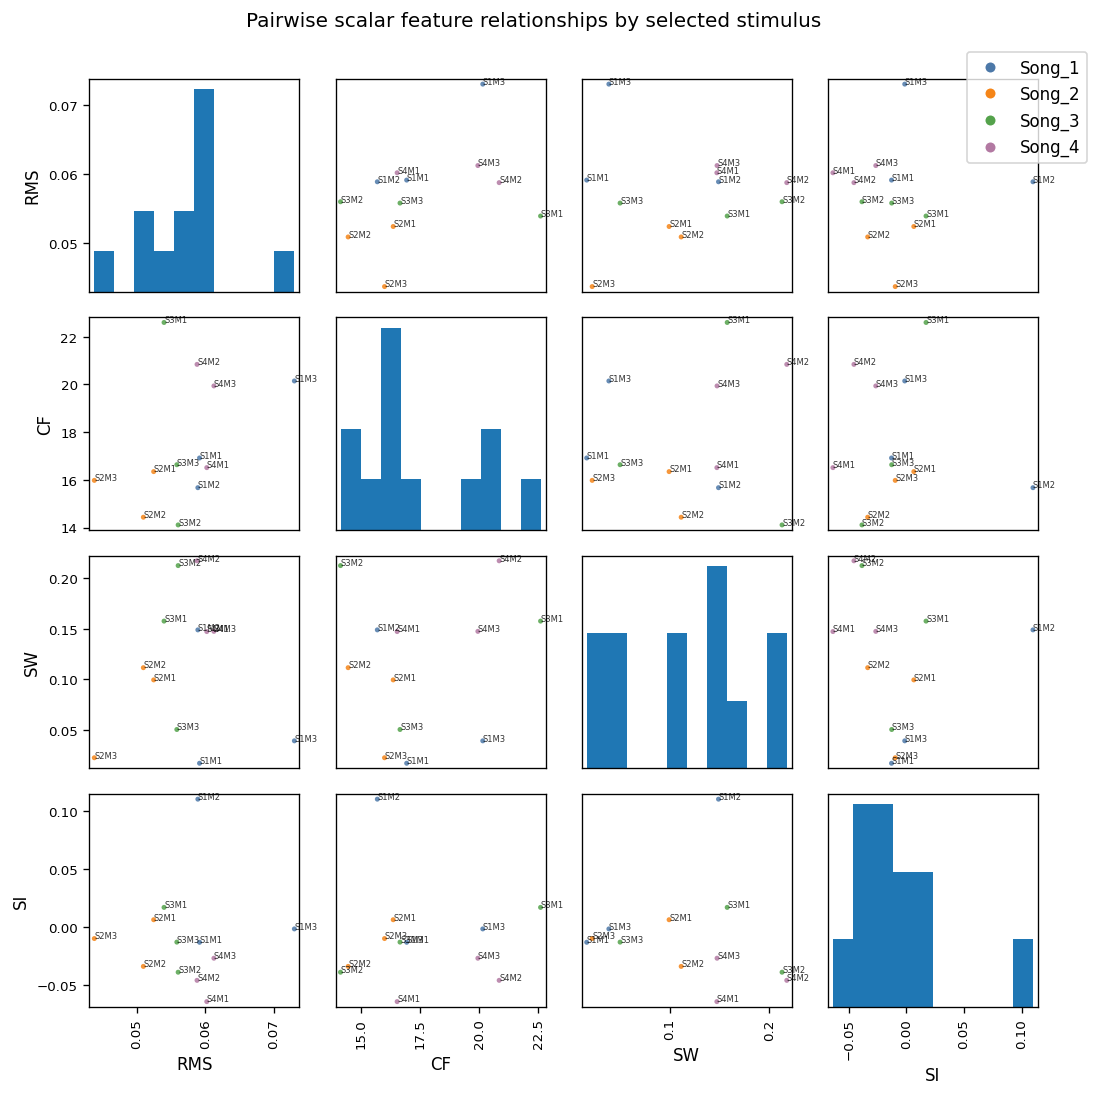

In [7]:
song_palette = {"Song_1": "#4C78A8", "Song_2": "#F58518", "Song_3": "#54A24B", "Song_4": "#B279A2"}
axes = scatter_matrix(
    scalar_df[scalar_cols],
    figsize=(9, 9),
    diagonal="hist",
    color=[song_palette[s] for s in scalar_df["song_id"]],
    alpha=0.85,
)
for i, y_feature in enumerate(scalar_cols):
    for j, x_feature in enumerate(scalar_cols):
        ax = axes[i, j]
        if i != j:
            for _, row in scalar_df.iterrows():
                ax.annotate(row["stimulus_id"].replace("Song_", "S").replace("_Mix_", "M"), (row[x_feature], row[y_feature]), fontsize=5, alpha=0.8)
fig = axes[0, 0].figure
fig.suptitle("Pairwise scalar feature relationships by selected stimulus", y=1.01)
handles = [plt.Line2D([0], [0], marker="o", color="w", label=song, markerfacecolor=color, markersize=7) for song, color in song_palette.items()]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.02, 0.98))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "scalar_feature_scatter_matrix.png")
plt.show()

## 8. Standardisation

The processed feature table includes within-song robust-scaled scalar columns from Stage 4. For participant-rating models, raw units should generally be transformed before modelling so coefficients are on comparable scales. The demonstration below uses ordinary z-scores across the twelve final stimuli for modelling interpretability; within-song robust scaling remains important evidence for selection, not necessarily the final modelling scale.

,stimulus_id,song_id,mix_id,scaled_rms_mean,scaled_crest_factor_mean,scaled_stereo_width,z_RMS,z_CF,z_SW,z_SI
0,Song_1_Mix_1,Song_1,Mix_1,-1.2379,-0.2624,-0.9449,0.3171,-0.2298,-1.4584,-0.0857
1,Song_1_Mix_2,Song_1,Mix_2,-1.2842,-0.7144,2.4858,0.2805,-0.7120,0.5199,2.8312
2,Song_1_Mix_3,Song_1,Mix_3,1.3785,0.9091,-0.3681,2.3830,1.0202,-1.1258,0.1868
3,Song_2_Mix_1,Song_2,Mix_1,0.7456,0.5287,0.1185,-0.6821,-0.4510,-0.2219,0.3738
4,Song_2_Mix_2,Song_2,Mix_2,0.4214,-2.2206,0.3238,-0.9070,-1.1913,-0.0406,-0.5775
5,Song_2_Mix_3,Song_2,Mix_3,-1.1185,0.0000,-1.1897,-1.9752,-0.5934,-1.3768,-0.0096
6,Song_3_Mix_1,Song_3,Mix_1,-0.4682,1.5643,1.2857,-0.4565,1.9699,0.6501,0.6255
7,Song_3_Mix_2,Song_3,Mix_2,0.1033,-1.8176,2.1012,-0.1492,-1.3165,1.4735,-0.6956
8,Song_3_Mix_3,Song_3,Mix_3,0.0504,-0.8120,-0.3066,-0.1776,-0.3393,-0.9575,-0.0823
9,Song_4_Mix_1,Song_4,Mix_1,0.0578,-1.3614,0.7511,0.4746,-0.3864,0.4952,-1.2948


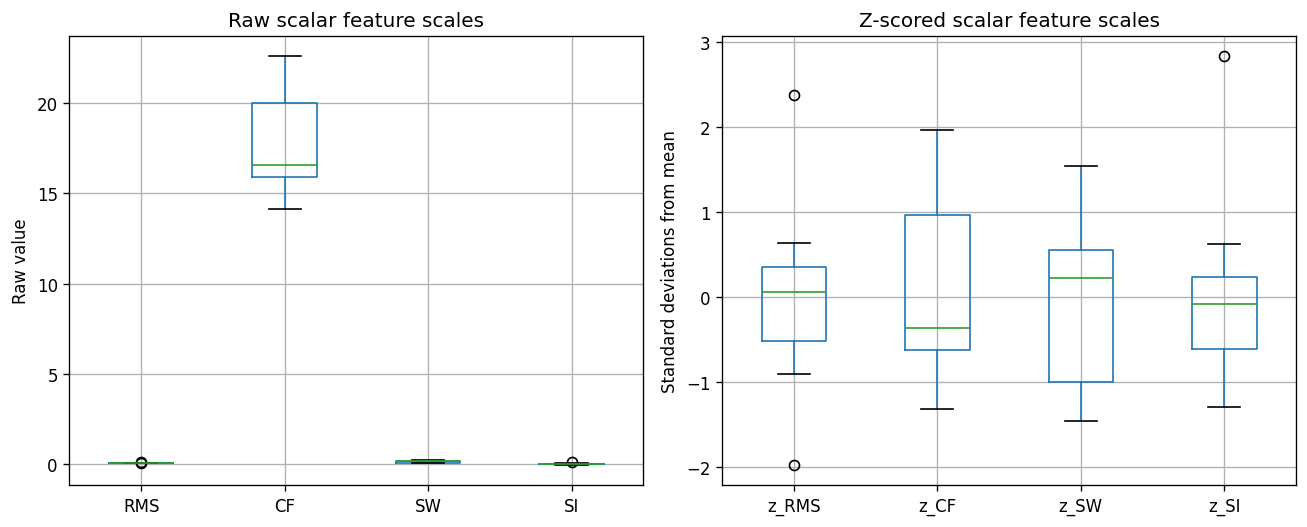

In [8]:
standardised_df = scalar_df.copy()
for feature in scalar_cols:
    standardised_df[f"z_{feature}"] = (standardised_df[feature] - standardised_df[feature].mean()) / standardised_df[feature].std(ddof=0)

scaled_cols_available = [c for c in ["scaled_rms_mean", "scaled_crest_factor_mean", "scaled_stereo_width", "scaled_stereo_imbalance"] if c in stimulus_features.columns]
standardisation_compare = stimulus_features[["stimulus_id", "song_id", "mix_id", *scaled_cols_available]].merge(
    standardised_df[["stimulus_id", *[f"z_{f}" for f in scalar_cols]]],
    on="stimulus_id",
    how="left",
)
display(standardisation_compare.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
scalar_df[scalar_cols].boxplot(ax=axes[0])
axes[0].set_title("Raw scalar feature scales")
axes[0].set_ylabel("Raw value")
standardised_df[[f"z_{f}" for f in scalar_cols]].boxplot(ax=axes[1])
axes[1].set_title("Z-scored scalar feature scales")
axes[1].set_ylabel("Standard deviations from mean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "raw_vs_standardised_features.png")
plt.show()

## 9. Stimulus Diversity in Bark PCA Space

Existing Bark PCA scores are available. Because PCA was fitted separately within each song, the axes are most defensible as within-song diagnostics. The faceted plot below avoids implying that `bark_pc_01` has an identical global meaning across songs.

,stimulus_id,song_id,mix_id,original_mix_name,bark_pc_01,bark_pc_02,available_bark_pc_count
0,Song_1_Mix_1,Song_1,Mix_1,PXL-L1,-10.9608,1.4309,9
1,Song_1_Mix_2,Song_1,Mix_2,PXL-L4,0.4081,-1.3337,9
2,Song_1_Mix_3,Song_1,Mix_3,McG-pro2,1.0479,-0.2722,9
3,Song_2_Mix_1,Song_2,Mix_1,McG-C,2.7843,-2.5560,5
4,Song_2_Mix_2,Song_2,Mix_2,McG-H,5.5370,3.1029,5
5,Song_2_Mix_3,Song_2,Mix_3,McG-pro1,-10.5268,-2.5366,5
6,Song_3_Mix_1,Song_3,Mix_1,DU-K,-4.9119,-4.7748,8
7,Song_3_Mix_2,Song_3,Mix_2,QUT-pro,7.4613,-0.9589,8
8,Song_3_Mix_3,Song_3,Mix_3,DU-N,-3.2665,-3.2631,8
9,Song_4_Mix_1,Song_4,Mix_1,McG-R,-10.1894,-0.4374,5


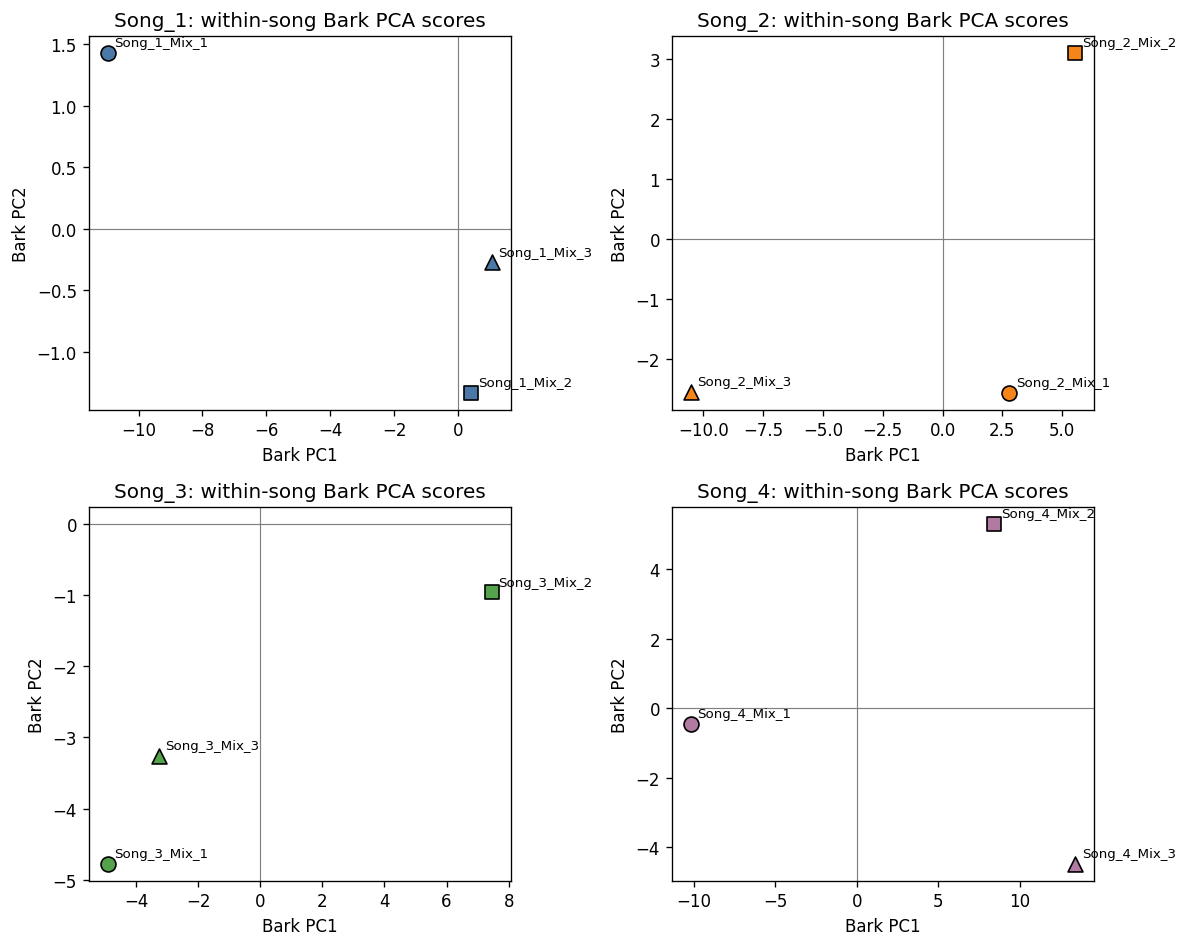

In [9]:
selected_pca = (
    selected[["stimulus_id", "neutral_song_id", "neutral_mix_id", "source_mix_id", "song", "original_mix_name"]]
    .rename(columns={"neutral_song_id": "song_id", "neutral_mix_id": "mix_id"})
    .merge(
    pca_scores.rename(columns={"mix_id": "source_mix_id"}),
    on="source_mix_id",
    how="left",
    suffixes=("", "_pca_source"),
)
)
pca_cols_selected = [c for c in selected_pca.columns if c.startswith("bark_pc_")]
selected_pca["available_bark_pc_count"] = selected_pca[pca_cols_selected].notna().sum(axis=1)
display(selected_pca[["stimulus_id", "song_id", "mix_id", "original_mix_name", "bark_pc_01", "bark_pc_02", "available_bark_pc_count"]].round(4))

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
shape_map = {"Mix_1": "o", "Mix_2": "s", "Mix_3": "^"}
for ax, song_id in zip(axes.ravel(), SONG_IDS := ["Song_1", "Song_2", "Song_3", "Song_4"]):
    sub = selected_pca[selected_pca["song_id"].eq(song_id)]
    for _, row in sub.iterrows():
        ax.scatter(row["bark_pc_01"], row["bark_pc_02"], marker=shape_map[row["mix_id"]], s=80, color=song_palette[song_id], edgecolor="black")
        ax.annotate(row["stimulus_id"], (row["bark_pc_01"], row["bark_pc_02"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.axvline(0, color="grey", linewidth=0.7)
    ax.set_title(f"{song_id}: within-song Bark PCA scores")
    ax.set_xlabel("Bark PC1")
    ax.set_ylabel("Bark PC2")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "selected_stimuli_bark_pca_by_song.png")
plt.show()

## 10. Model Feasibility

A feature-based model such as `rating ~ episode * (RMS + CF + SW + SI)` would estimate four main feature slopes plus episode interactions. With five episodes, that implies four feature effects and sixteen episode-by-feature contrasts before random participant effects. The rating table has many rows, but the feature variation exists at only twelve stimulus points. The effective stimulus-level sample size is therefore twelve, not 1,200.

This makes a rich interaction model statistically fragile and vulnerable to overfitting. A more realistic next model would start with standardised scalar main effects plus episode main effects and, at most, a very small number of pre-specified interactions. The interaction structure should be justified by the dissertation question rather than added mechanically.

## 11. BS Recommendation

No scalar BS column was found. The repository stores BS as 48 raw Bark mid/side bands and also provides within-song Bark PCA scores used for mix selection. The PCA is valuable evidence that Bark information influenced stimulus selection, but because it is fitted within each song, a PC score should not be treated as a simple global acoustic predictor unless the modelling section explicitly defines that convention.

In [10]:
strongest_pearson = correlation_flags[correlation_flags["method"].eq("pearson")].iloc[0].to_dict()
strongest_spearman = correlation_flags[correlation_flags["method"].eq("spearman")].iloc[0].to_dict()
scalar_near_constant = feature_summary.loc[feature_summary["near_constant"], "feature"].tolist()
retained_pc_counts = pca_retained_summary.set_index("song")["retained_components"].astype(int).to_dict()

recommendation = {
    "authoritative_final_stimulus_source": str(SOURCE_PATHS["final_selected_mixes"].relative_to(REPO_ROOT)),
    "authoritative_raw_feature_source": str(SOURCE_PATHS["raw_diffmst_features"].relative_to(REPO_ROOT)),
    "recommended_scalar_predictors": ["z_RMS", "z_CF", "z_SW", "z_SI"],
    "standardisation_recommended": True,
    "standardisation_reason": "Raw feature units differ substantially; z-scoring across the final selected stimuli gives comparable coefficient scales for the next model.",
    "bs_representation_found": "48 raw Bark mid/side bands plus within-song Bark PCA scores",
    "bs_scalar_found": False,
    "bs_recommendation": "Do not invent a scalar BS value. For the next dissertation model, either exclude BS initially or include a very small pre-specified Bark PCA representation only with a clear caveat that existing PCs are within-song selection diagnostics.",
    "bark_pca_available": True,
    "retained_bark_pc_counts_by_song": retained_pc_counts,
    "feature_interactions_recommended_initially": False,
    "interaction_reason": "Only twelve stimulus-level feature combinations are available; episode-by-feature interactions would be high risk.",
    "strongest_pearson_correlation": strongest_pearson,
    "strongest_spearman_correlation": strongest_spearman,
    "near_constant_scalar_features": scalar_near_constant,
}
display(pd.DataFrame([recommendation]).T.rename(columns={0: "recommendation"}))

,recommendation
authoritative_final_stimulus_source,outputs\stimulus_selection\09_current_frontend...
authoritative_raw_feature_source,outputs\stimulus_selection\03_feature_extracti...
recommended_scalar_predictors,"[z_RMS, z_CF, z_SW, z_SI]"
standardisation_recommended,True
standardisation_reason,Raw feature units differ substantially; z-scor...
bs_representation_found,48 raw Bark mid/side bands plus within-song Ba...
bs_scalar_found,False
bs_recommendation,Do not invent a scalar BS value. For the next ...
bark_pca_available,True
retained_bark_pc_counts_by_song,"{'Red To Blue': 5, 'In The Meantime': 8, 'Lead..."


## 12. Recommended Feature Representation

For the next feature-based Bayesian model, the most defensible starting representation is:

- Standardised scalar predictors: `z_RMS`, `z_CF`, `z_SW`, and `z_SI`.
- Episode as a categorical fixed effect.
- Participant as a random intercept.
- No automatic Episode x Feature interaction in the first feature model.
- BS excluded from the first feature model unless the dissertation explicitly chooses a dimensionality-reduced Bark representation.

The scalar predictors are available for all twelve selected stimuli and have direct feature definitions. They should be standardised because their units and scales differ. The Bark Spectrum should not be reduced to a scalar by assumption. Existing Bark PCA scores should be treated as Stage 4 selection diagnostics unless a later notebook defines a modelling-specific Bark representation and explains the cross-song comparability issue.

## 13. Export Tables and Recommendation

The exports are machine-readable summaries for the next Phase 3B notebook and dissertation appendix.

In [11]:
feature_summary_path = OUTPUT_DIR / "feature_summary.csv"
correlation_path = OUTPUT_DIR / "correlation_matrix.csv"
spearman_path = OUTPUT_DIR / "spearman_correlation_matrix.csv"
stimulus_feature_path = OUTPUT_DIR / "stimulus_feature_table.csv"
recommendation_path = OUTPUT_DIR / "feature_recommendation.json"
pca_summary_path = OUTPUT_DIR / "bark_pca_summary.csv"
pca_selected_path = OUTPUT_DIR / "selected_stimuli_bark_pca_scores.csv"
loaded_files_path = OUTPUT_DIR / "loaded_feature_sources.csv"

feature_summary.to_csv(feature_summary_path, index=False)
pearson_corr.to_csv(correlation_path)
spearman_corr.to_csv(spearman_path)
coverage_table.to_csv(stimulus_feature_path, index=False)
pca_retained_summary.to_csv(pca_summary_path, index=False)
selected_pca[["stimulus_id", "song_id", "mix_id", "source_mix_id", "original_mix_name", *pca_cols_selected]].to_csv(pca_selected_path, index=False)
loaded_files_df.to_csv(loaded_files_path, index=False)
recommendation_path.write_text(json.dumps(recommendation, indent=2), encoding="utf-8")

export_manifest = pd.DataFrame(
    [
        {"artifact": "feature_summary", "path": str(feature_summary_path.relative_to(REPO_ROOT))},
        {"artifact": "pearson_correlation_matrix", "path": str(correlation_path.relative_to(REPO_ROOT))},
        {"artifact": "spearman_correlation_matrix", "path": str(spearman_path.relative_to(REPO_ROOT))},
        {"artifact": "stimulus_feature_table", "path": str(stimulus_feature_path.relative_to(REPO_ROOT))},
        {"artifact": "feature_recommendation", "path": str(recommendation_path.relative_to(REPO_ROOT))},
        {"artifact": "bark_pca_summary", "path": str(pca_summary_path.relative_to(REPO_ROOT))},
        {"artifact": "selected_stimuli_bark_pca_scores", "path": str(pca_selected_path.relative_to(REPO_ROOT))},
        {"artifact": "loaded_feature_sources", "path": str(loaded_files_path.relative_to(REPO_ROOT))},
    ]
)
display(export_manifest)

,artifact,path
0,feature_summary,outputs\statistical_baseline\mst_feature_explo...
1,pearson_correlation_matrix,outputs\statistical_baseline\mst_feature_explo...
2,spearman_correlation_matrix,outputs\statistical_baseline\mst_feature_explo...
3,stimulus_feature_table,outputs\statistical_baseline\mst_feature_explo...
4,feature_recommendation,outputs\statistical_baseline\mst_feature_explo...
5,bark_pca_summary,outputs\statistical_baseline\mst_feature_explo...
6,selected_stimuli_bark_pca_scores,outputs\statistical_baseline\mst_feature_explo...
7,loaded_feature_sources,outputs\statistical_baseline\mst_feature_explo...


## 14. Execution Summary

This final code cell records the key findings for auditability.

In [12]:
execution_summary = pd.DataFrame(
    [
        {"item": "notebook", "value": "notebooks/Statistical Baseline/_03_mst_feature_exploration.ipynb"},
        {"item": "loaded_files", "value": "; ".join(loaded_files_df.loc[loaded_files_df["loaded"], "filename"])},
        {"item": "scalar_features_available", "value": ", ".join(scalar_cols)},
        {"item": "bs_representation", "value": "48 Bark mid/side raw columns; within-song PCA scores available"},
        {"item": "pca_available", "value": True},
        {"item": "strongest_pearson", "value": f"{strongest_pearson['feature_a']} vs {strongest_pearson['feature_b']}: r={strongest_pearson['r']:.3f}"},
        {"item": "strongest_spearman", "value": f"{strongest_spearman['feature_a']} vs {strongest_spearman['feature_b']}: rho={strongest_spearman['r']:.3f}"},
        {"item": "bs_recommendation", "value": recommendation["bs_recommendation"]},
        {"item": "recommended_predictors", "value": ", ".join(recommendation["recommended_scalar_predictors"])},
        {"item": "standardisation_recommended", "value": True},
        {"item": "feature_interactions_feasible_initially", "value": False},
        {"item": "export_directory", "value": str(OUTPUT_DIR.relative_to(REPO_ROOT))},
    ]
)
display(execution_summary)
execution_summary.to_csv(OUTPUT_DIR / "execution_summary.csv", index=False)

,item,value
0,notebook,notebooks/Statistical Baseline/_03_mst_feature...
1,loaded_files,outputs\stimulus_selection\03_feature_extracti...
2,scalar_features_available,"RMS, CF, SW, SI"
3,bs_representation,48 Bark mid/side raw columns; within-song PCA ...
4,pca_available,True
5,strongest_pearson,RMS vs CF: r=0.402
6,strongest_spearman,RMS vs CF: rho=0.399
7,bs_recommendation,Do not invent a scalar BS value. For the next ...
8,recommended_predictors,"z_RMS, z_CF, z_SW, z_SI"
9,standardisation_recommended,True


## 15. Limitations and Next Steps

- Only twelve final stimuli exist, so feature-level inference is limited by twelve stimulus-level feature combinations.
- Feature-based models cannot create information absent from the stimuli; they can only estimate associations supported by the selected stimulus set.
- Possible multicollinearity should be monitored, especially for any strongly correlated scalar pairs identified above.
- BS representation remains uncertain for modelling: the repository contains a 48-column Bark vector and within-song PCA outputs, but no agreed scalar BS variable.
- The recommended next statistical model is a cautious standardised scalar-feature mixed model, for example `rating ~ episode + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id)`, before considering any pre-specified interactions or Bark PCA sensitivity analyses.